In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Customer Churn.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

# Here we replaced the blank values with 0

In [5]:
df["TotalCharges"] = df["TotalCharges"].astype("float")

# Here the datatype is changed to float

In [6]:
def convo(value):
    if value == 1:
        return "yes"
    else:
        return "no"
df['SeniorCitizen'] = df["SeniorCitizen"].apply(convo)

# In the table, the values are in 0 and 1 so those are converted to "yes" and "no"

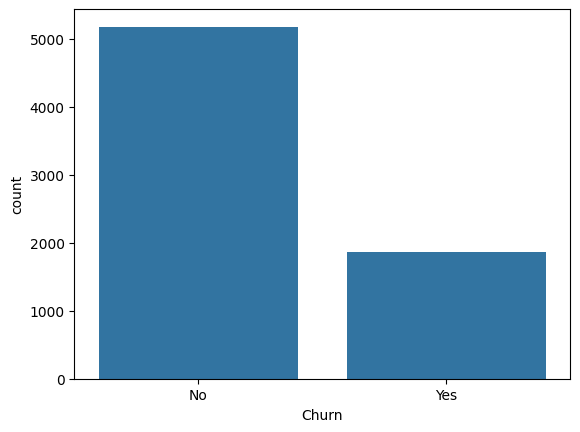

In [7]:
# Lets check the citizens who churned out
# sns.countplot(x = 'Churn', data = df)
# ax.bar_label(ax.coontainers[0])
# plt.show()
ax = sns.countplot(x='Churn', data=df)
plt.show()

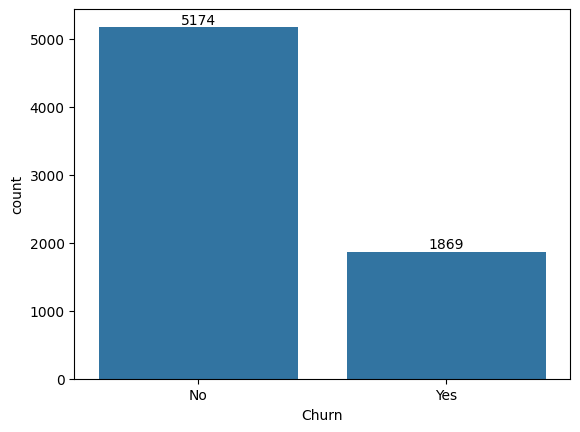

In [8]:
# to see the count of customers in the graph, then:
ax = sns.countplot(x = 'Churn', data =df)
ax.bar_label(ax.containers[0])
plt.show()

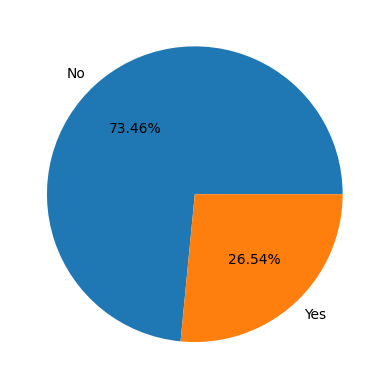

In [9]:
# if want in percentage, then:
gb = df.groupby("Churn").agg({'Churn':"count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.show()

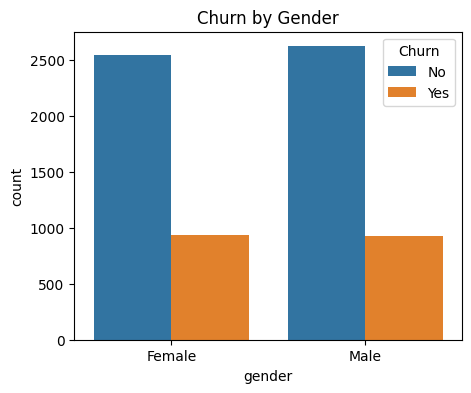

In [16]:
# Churn by Gender
plt.figure(figsize = (5, 4))
sns.countplot(x = "gender", data = df, hue = "Churn")
plt.title("Churn by Gender")
plt.show()


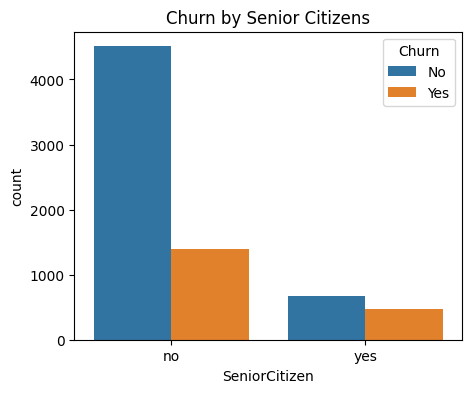

In [18]:
# Churn by Gender
plt.figure(figsize = (5, 4))
sns.countplot(x = "SeniorCitizen", data = df, hue = "Churn")
plt.title("Churn by Senior Citizens")
plt.show()


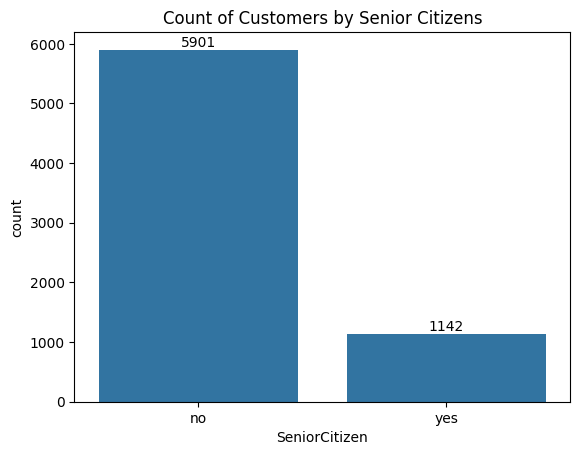

In [23]:
ax = sns.countplot(x = "SeniorCitizen", data = df)
ax.bar_label(ax.containers[0])  
plt.title("Count of Customers by Senior Citizens")
plt.show()

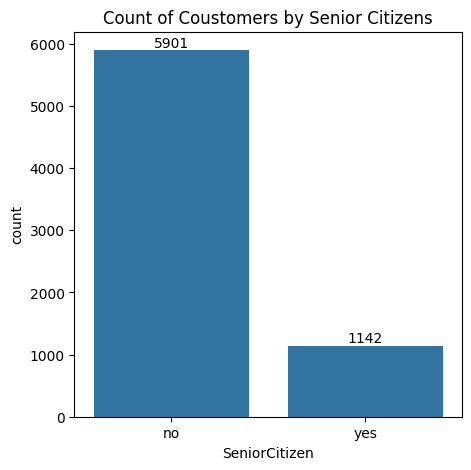

In [53]:
plt.figure(figsize = (5,5))
ax = sns.countplot(x = 'SeniorCitizen', data = df)
ax.bar_label(ax.containers[0])
plt.title("Count of Coustomers by Senior Citizens")
plt.show()

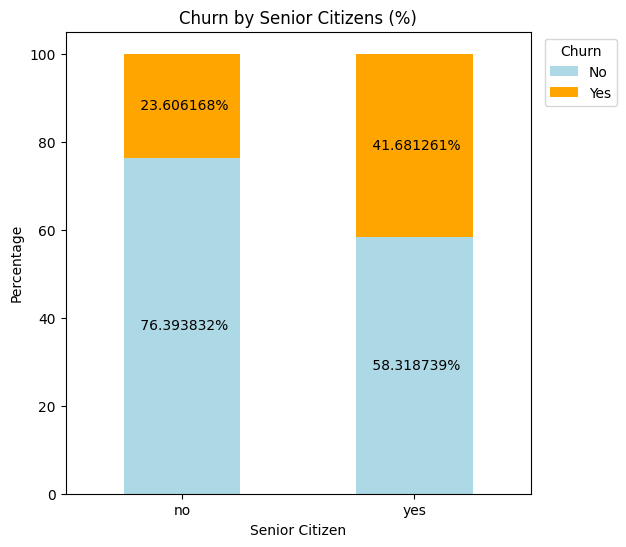

In [48]:
total_counts = df.groupby('SeniorCitizen')['Churn'].value_counts (normalize = True).unstack() * 100
fig , ax = plt.subplots(figsize = (6,6))
total_counts.plot(kind = 'bar', stacked = True, ax=ax, color = ['lightblue', 'orange'])
# add % labels on bars
for p in ax.patches:
    width, height =p.get_width(), p.get_height()
    x,y = p.get_xy()
    ax.text(x + width/2, y + height/2, f'{height : 1f}%', ha = 'center', va = 'center')
plt.title("Churn by Senior Citizens (%)")
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title = 'Churn', loc = 'upper right', bbox_to_anchor=(1.2,1))
plt.show()

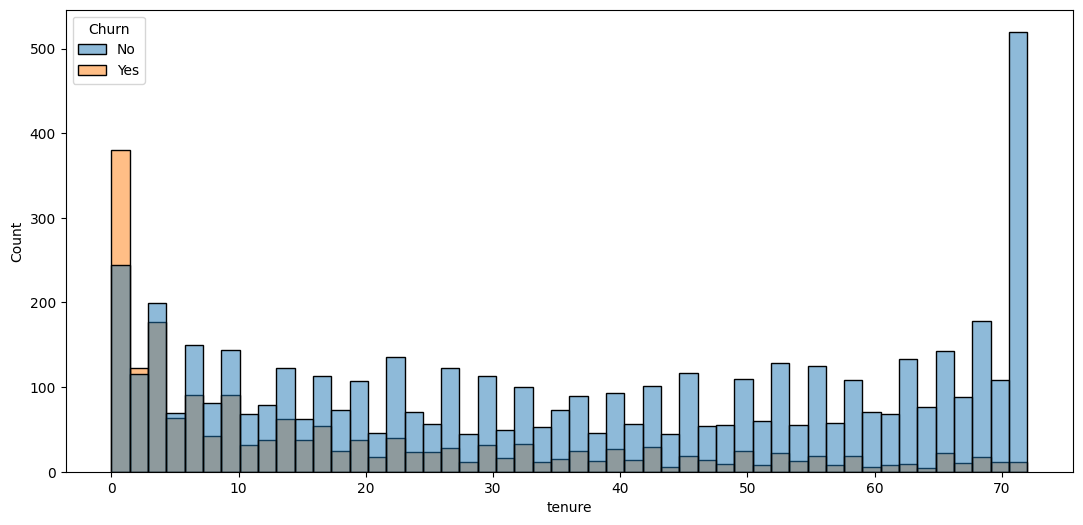

In [62]:
# Based on Tenure
plt.figure(figsize = (13,6))
sns.histplot(x = "tenure", data = df, hue = "Churn", bins = 50)
plt.show()

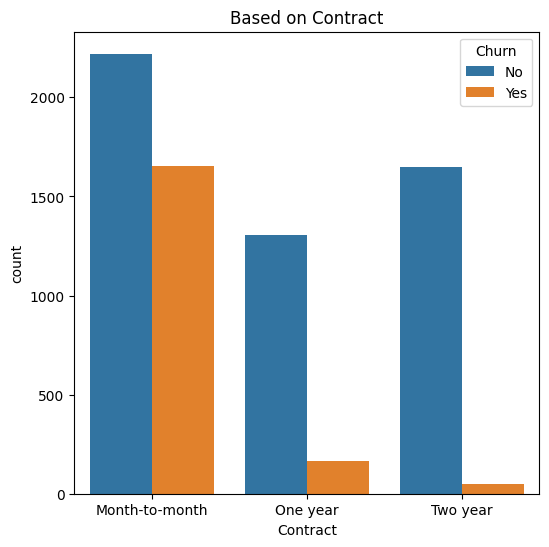

In [66]:
# Based on Tenure
plt.figure(figsize = (6,6))
sns.countplot(x = "Contract", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
plt.title('Based on Contract')
plt.show()

# Conclusion is, those who had contact on monthly basis churn out easily compare to Yearly contracts

In [67]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

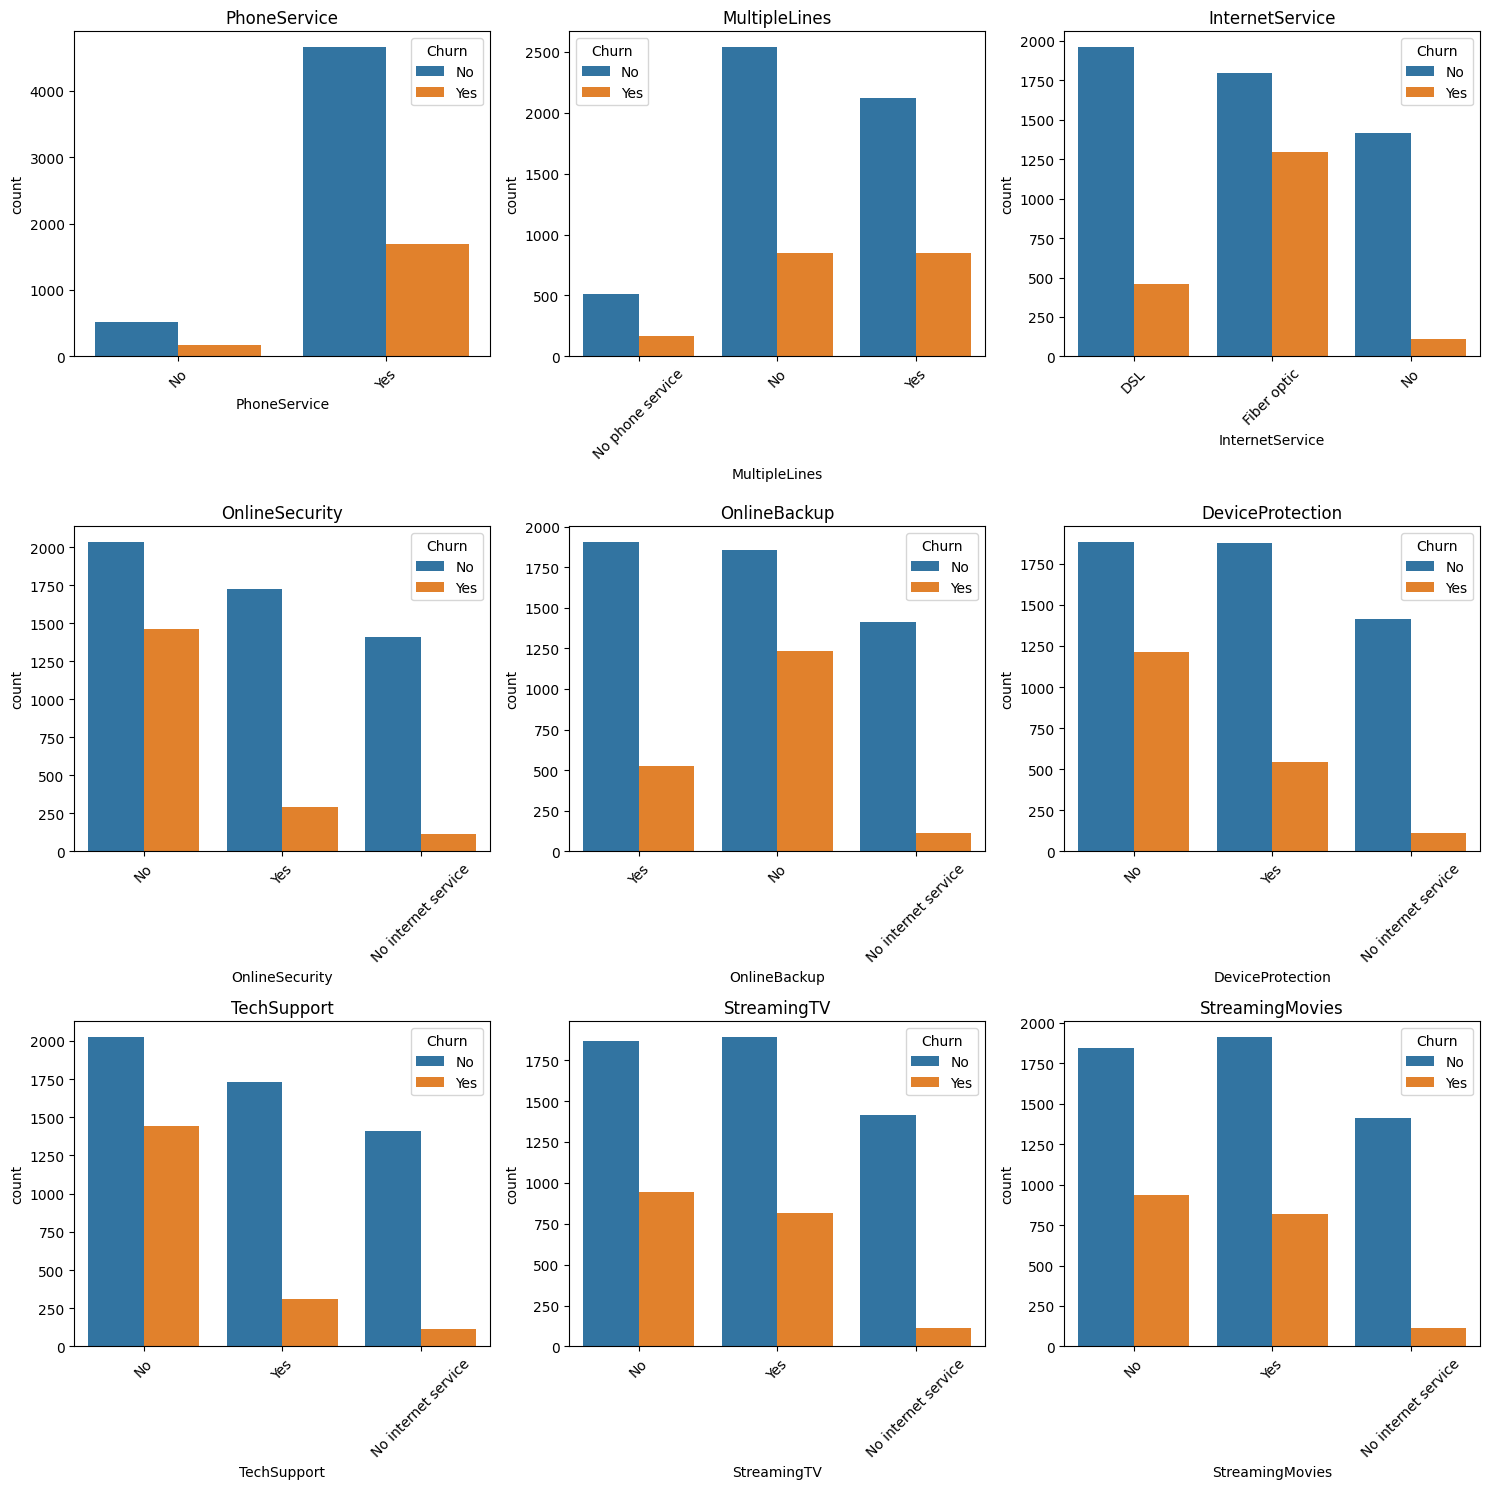

In [74]:
services = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# create grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,15))

axes = axes.flatten()  # convert to 1D for easy loop

# loop through columns
for i, col in enumerate(services):
    ax = axes[i]
    sns.countplot(x=col, data=df, ax=ax, hue = df['Churn'])
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# 

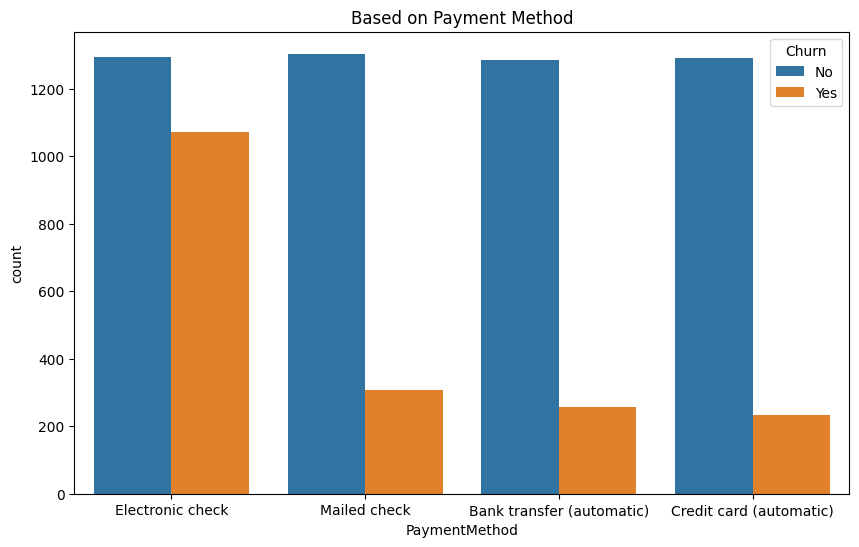

In [78]:
# Based on Payment Method
plt.figure(figsize = (10,6))
sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.legend(title='Churn', loc='upper left', bbox_to_anchor=(1,1))
plt.title('Based on Payment Method')
plt.show()